# ⚽ **Analisi del Fattore Campo in Serie A**

**Corso:** Data Science

**Obiettivo:** Visualizzare l'effetto del fattore campo (Home Advantage) nelle  stagioni passate di Serie A  

**Versione Python:** 3.12.12  

**Nome Gruppo**: Gruppo n.3

**Membri gruppo :** Perrone Michele, Anthony Santino, Stefano Narducci

---

## 📋 Indice
1. **Data Collection** (recupero dati)
2. **Data Cleaning** (pulizia dati)
 3. Export Nuovo **File CSV** dopo pulizia
  4. Exploratory Data Analysis (**EDA**)  (esplorazione visiva)

5. Analisi Statistica di un **caso specifico**


---

### 🎯OBIETTIVO:
Rispondere alla seguente domanda : **Esiste un vantaggio significativo per le squadre che giocano in casa in Serie A?**  Analizzeremo vittorie, gol segnati e punti ottenuti confrontando prestazioni casalinghe vs trasferte degli ultimi anni.

# **1**) **DATA COLLECTION**

##  **Import Librerie**
Importiamo le librerie necessarie per lavorare con i dati :

In [1]:
# Importo pandas per lavorare con le tabelle
import pandas as pd

# Importo numpy per calcoli matematici
import numpy as np

# Importo matplotlib per fare grafici
import matplotlib.pyplot as plt

# Importo seaborn per grafici più belli
import seaborn as sns

# Importo scipy per analisi statistiche
from scipy import stats

# Nascondo i warning che non servono
import warnings
warnings.filterwarnings('ignore')

# Stampo un messaggio di conferma
print(" Librerie caricate con successo")

 Librerie caricate con successo


## **Caricamento Dataset**

Scarichiamo i dati delle ultime 4 stagioni (2020/21 - 2023/24) da football-data.co.uk, un database open source gratuito con statistiche dettagliate :

In [2]:

# Creo una lista vuota dove mettere i dati
lista_dati = []

# URL stagione 2020/21
url_2021 = 'https://www.football-data.co.uk/mmz4281/2021/I1.csv'
df_2021 = pd.read_csv(url_2021, encoding='latin-1')  # Leggo il file CSV
df_2021['Stagione'] = '2020/21'  # Aggiungo la colonna stagione
lista_dati.append(df_2021)  # Aggiungo alla lista
print(" Stagione 2020/21 scaricata")

# URL stagione 2021/22
url_2122 = 'https://www.football-data.co.uk/mmz4281/2122/I1.csv'
df_2122 = pd.read_csv(url_2122, encoding='latin-1')
df_2122['Stagione'] = '2021/22'
lista_dati.append(df_2122)
print(" Stagione 2021/22 scaricata")

# URL stagione 2022/23
url_2223 = 'https://www.football-data.co.uk/mmz4281/2223/I1.csv'
df_2223 = pd.read_csv(url_2223, encoding='latin-1')
df_2223['Stagione'] = '2022/23'
lista_dati.append(df_2223)
print(" Stagione 2022/23 scaricata")

# URL stagione 2023/24
url_2324 = 'https://www.football-data.co.uk/mmz4281/2324/I1.csv'
df_2324 = pd.read_csv(url_2324, encoding='latin-1')
df_2324['Stagione'] = '2023/24'
lista_dati.append(df_2324)
print(" Stagione 2023/24 scaricata")

# Unisco tutti i dati in un unico DataFrame
df_raw = pd.concat(lista_dati, ignore_index=True)

print(f"\n Totale partite scaricate: {len(df_raw)}")

 Stagione 2020/21 scaricata
 Stagione 2021/22 scaricata
 Stagione 2022/23 scaricata
 Stagione 2023/24 scaricata

 Totale partite scaricate: 1520


# **Prima Ispezione del Dataset**

### Visualizziamo i dati per capire cosa contengono

In [3]:
# Dimensioni del dataset

print(" DIMENSIONI DATASET : ")
print(f" Righe (partite): {df_raw.shape[0]} ")   #shape mi permette di visulizzare una tupla(righe,colonne,0,1)
print(f" Colonne (variabili): {df_raw.shape[1]} ")


 DIMENSIONI DATASET : 
 Righe (partite): 1520 
 Colonne (variabili): 106 


In [4]:
# Info generale sul dataset
print("\n INFORMAZIONI GENERALI SUL DATASET:\n")
print(df_raw.info())   #.info serve per avere tutte le informazioni di qualcosa


 INFORMAZIONI GENERALI SUL DATASET:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Columns: 106 entries, Div to Stagione
dtypes: float64(82), int64(16), object(8)
memory usage: 1.2+ MB
None


In [5]:

# Ultime 5 righe
print("\n ULTIME 5 RIGHE DEL DATASET:\n")
display(df_raw.tail()) #tail è l'opposto di head, infatti restituisce le ultime 5 righe finali


 ULTIME 5 RIGHE DEL DATASET:



,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Stagione
1515,I1,26/05/2024,19:45,Empoli,Roma,2,1,H,1,1,...,-0.25,1.95,1.98,1.95,1.97,2.02,2.00,1.93,1.92,2023/24
1516,I1,26/05/2024,19:45,Frosinone,Udinese,0,1,A,0,0,...,-0.25,2.13,1.81,2.22,1.74,2.22,1.83,2.11,1.76,2023/24
1517,I1,26/05/2024,19:45,Lazio,Sassuolo,1,1,D,0,0,...,-1.50,1.99,1.94,1.99,1.93,2.02,2.00,1.93,1.93,2023/24
1518,I1,26/05/2024,19:45,Verona,Inter,2,2,D,2,2,...,1.25,2.05,1.88,2.07,1.86,2.07,1.97,1.98,1.87,2023/24
1519,I1,02/06/2024,17:00,Atalanta,Fiorentina,2,3,A,2,3,...,-1.00,1.99,1.94,1.99,1.93,2.04,1.96,1.95,1.90,2023/24


In [6]:
# Statistiche descrittive per colonne numeriche
print("\n STATISTICHE DESCRITTIVE (colonne numeriche principali):\n")
display(df_raw[['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST']].describe()) # describe ci permette di generare istantaneamente un riepilogo statistico di un DataFrame ( valori non vuoti, valore medio,deviaz standard,val.min e max, mediana)


 STATISTICHE DESCRITTIVE (colonne numeriche principali):



,FTHG,FTAG,HS,AS,HST,AST
count,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000
mean,1.494079,1.278947,13.353947,11.324342,4.836184,4.155263
std,1.250134,1.145655,5.351230,4.797760,2.606546,2.421834
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,10.000000,8.000000,3.000000,2.000000
50%,1.000000,1.000000,13.000000,11.000000,5.000000,4.000000
75%,2.000000,2.000000,17.000000,14.000000,6.000000,6.000000
max,8.000000,7.000000,46.000000,31.000000,16.000000,15.000000


In [7]:
# Prime 5 righe
print("\n PRIME 5 RIGHE DEL DATASET:\n")
display(df_raw.head()) #head È il comando che "taglia" il dataset e tiene solo le prime 5 righe in questo caso.


 PRIME 5 RIGHE DEL DATASET:



,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Stagione
0,I1,19/09/2020,17:00,Fiorentina,Torino,1,0,H,0,0,...,-0.50,1.86,2.07,1.84,2.10,1.87,2.10,1.84,2.03,2020/21
1,I1,19/09/2020,19:45,Verona,Roma,0,0,D,0,0,...,0.75,1.89,2.04,1.91,2.01,1.95,2.07,1.88,1.99,2020/21
2,I1,20/09/2020,11:30,Parma,Napoli,0,2,A,0,0,...,1.00,2.05,1.75,2.15,1.79,2.18,1.86,2.09,1.79,2020/21
3,I1,20/09/2020,14:00,Genoa,Crotone,4,1,H,3,1,...,-0.25,2.13,1.81,2.15,1.80,2.16,1.84,2.10,1.79,2020/21
4,I1,20/09/2020,17:00,Sassuolo,Cagliari,1,1,D,0,0,...,-0.75,1.84,2.09,1.84,2.10,1.89,2.14,1.83,2.04,2020/21


# **2) DATA CLEANING**

###  **Selezione e Rinomina Colonne**

Selezioniamo solo le colonne utili per l'analisi e le rinominiamo:

In [8]:
# Seleziona le colonne rilevanti per l'analisi
colonne_selezionate = [
    'Date',       # Data della partita
    'Stagione',   # Stagione
    'HomeTeam',   # Squadra di casa
    'AwayTeam',   # Squadra in trasferta
    'FTHG',       # Full Time Home Goals (gol casa a fine partita)
    'FTAG',       # Full Time Away Goals (gol trasferta a fine partita)
    'FTR',        # Full Time Result (H=Home win, D=Draw, A=Away win)
    'HS',         # Home Shots (tiri totali casa)
    'AS',         # Away Shots (tiri totali trasferta)
    'HST',        # Home Shots on Target (tiri in porta casa)
    'AST'         # Away Shots on Target (tiri in porta trasferta)
]

# Crea nuovo DataFrame con solo le colonne selezionate
df = df_raw[colonne_selezionate].copy()

print("="*60)
print(" COLONNE SELEZIONATE")
print("="*60)
for i, col in enumerate(colonne_selezionate, 1):
    print(f"{i:2d}. {col}")
print("="*60)
print(f"\nNuovo dataset: {df.shape[0]} righe × {df.shape[1]} colonne") # in sintesi

 COLONNE SELEZIONATE
 1. Date
 2. Stagione
 3. HomeTeam
 4. AwayTeam
 5. FTHG
 6. FTAG
 7. FTR
 8. HS
 9. AS
10. HST
11. AST

Nuovo dataset: 1520 righe × 11 colonne


In [9]:
# Rinominazione colonne per maggiore chiarezza:
df = df.rename(columns={
    'Date': 'Data',
    'HomeTeam': 'Squadra_Casa',
    'AwayTeam': 'Squadra_Trasferta',
    'FTHG': 'Gol_Casa',
    'FTAG': 'Gol_Trasferta',
    'FTR': 'Risultato',
    'HS': 'Tiri_Casa',
    'AS': 'Tiri_Trasferta',
    'HST': 'Tiri_Porta_Casa',
    'AST': 'Tiri_Porta_Trasferta'
})

print(" COLONNE RINOMINATE IN ITALIANO:\n")
for col in df.columns:
    print(f"  • {col}")

print("\n Anteprima con nuovi nomi:")
display(df.head())

 COLONNE RINOMINATE IN ITALIANO:

  • Data
  • Stagione
  • Squadra_Casa
  • Squadra_Trasferta
  • Gol_Casa
  • Gol_Trasferta
  • Risultato
  • Tiri_Casa
  • Tiri_Trasferta
  • Tiri_Porta_Casa
  • Tiri_Porta_Trasferta

 Anteprima con nuovi nomi:


,Data,Stagione,Squadra_Casa,Squadra_Trasferta,Gol_Casa,Gol_Trasferta,Risultato,Tiri_Casa,Tiri_Trasferta,Tiri_Porta_Casa,Tiri_Porta_Trasferta
0,19/09/2020,2020/21,Fiorentina,Torino,1,0,H,17,6,8,3
1,19/09/2020,2020/21,Verona,Roma,0,0,D,9,15,7,7
2,20/09/2020,2020/21,Parma,Napoli,0,2,A,4,12,2,7
3,20/09/2020,2020/21,Genoa,Crotone,4,1,H,10,11,8,5
4,20/09/2020,2020/21,Sassuolo,Cagliari,1,1,D,21,8,10,4


**Analisi Valori Nulli**

Contiamo e ordiniamo i valori mancanti per ogni colonna

In [10]:

# Conta valori nulli per ogni colonna
valori_nulli = df.isnull().sum()

# Ordina in modo decrescente
valori_nulli_ordinati = valori_nulli.sort_values(ascending=False)

# Calcola anche la percentuale
percentuali_nulli = (valori_nulli_ordinati / len(df) * 100).round(2)

# Crea DataFrame per visualizzazione migliore
tabella_nulli = pd.DataFrame({
    'Colonna': valori_nulli_ordinati.index,
    'Valori Nulli': valori_nulli_ordinati.values,
    'Percentuale (%)': percentuali_nulli.values
})

print("="*60)
print(" ANALISI VALORI NULLI (ordinati in modo decrescente)")
print("="*60)
display(tabella_nulli)
print("="*60)

# Totale valori nulli
totale_nulli = valori_nulli.sum()
totale_celle = df.shape[0] * df.shape[1]
perc_totale = (totale_nulli / totale_celle * 100).round(2)

print(f"\n📊 Totale valori nulli: {totale_nulli} su {totale_celle} celle ({perc_totale}%)")

 ANALISI VALORI NULLI (ordinati in modo decrescente)


,Colonna,Valori Nulli,Percentuale (%)
0,Data,0,0.0
1,Stagione,0,0.0
2,Squadra_Casa,0,0.0
3,Squadra_Trasferta,0,0.0
4,Gol_Casa,0,0.0
5,Gol_Trasferta,0,0.0
6,Risultato,0,0.0
7,Tiri_Casa,0,0.0
8,Tiri_Trasferta,0,0.0
9,Tiri_Porta_Casa,0,0.0



📊 Totale valori nulli: 0 su 16720 celle (0.0%)


In [11]:
# Rimuovi righe con valori nulli nelle colonne critiche
print("PULIZIA VALORI NULLI...\n")

righe_prima = len(df)

# Rimuovi righe con valori nulli in colonne essenziali
# (manteniamo le partite solo se hanno i dati principali)
df = df.dropna(subset=['Gol_Casa', 'Gol_Trasferta', 'Risultato'])

righe_dopo = len(df)
righe_rimosse = righe_prima - righe_dopo

print(f" Righe prima della pulizia: {righe_prima}")
print(f" Righe dopo la pulizia: {righe_dopo}")
print(f"  Righe rimosse: {righe_rimosse}")

if righe_rimosse > 0:
    print(f"\n  Rimosse {righe_rimosse} partite con dati mancanti (probabilmente non ancora giocate)")
else:
    print("\nNessuna riga rimossa - dataset completo!")

PULIZIA VALORI NULLI...

 Righe prima della pulizia: 1520
 Righe dopo la pulizia: 1520
  Righe rimosse: 0

Nessuna riga rimossa - dataset completo!


 **Normalizzazione Nomi Squadre**

Convertiamo le abbreviazioni in nomi completi delle squadre

In [12]:
# Mostra i nomi attuali delle squadre
print("🔍 NOMI SQUADRE ATTUALI (prima della normalizzazione):\n")
squadre_uniche = sorted(set(df['Squadra_Casa'].unique()) | set(df['Squadra_Trasferta'].unique()))
for i, squadra in enumerate(squadre_uniche, 1):
    print(f"{i:2d}. {squadra}")

print(f"\n✅ Totale squadre uniche: {len(squadre_uniche)}")

🔍 NOMI SQUADRE ATTUALI (prima della normalizzazione):

 1. Atalanta
 2. Benevento
 3. Bologna
 4. Cagliari
 5. Cremonese
 6. Crotone
 7. Empoli
 8. Fiorentina
 9. Frosinone
10. Genoa
11. Inter
12. Juventus
13. Lazio
14. Lecce
15. Milan
16. Monza
17. Napoli
18. Parma
19. Roma
20. Salernitana
21. Sampdoria
22. Sassuolo
23. Spezia
24. Torino
25. Udinese
26. Venezia
27. Verona

✅ Totale squadre uniche: 27


In [13]:
# Dizionario di mapping:  → nome completo in maiuscolo per maggiore chia
mapping_squadre = {
    'Atalanta': 'ATALANTA',
    'Bologna': 'BOLOGNA',
    'Cagliari': 'CAGLIARI',
    'Empoli': 'EMPOLI',
    'Fiorentina': 'FIORENTINA',
    'Genoa': 'GENOA',
    'Inter': 'INTER',
    'Juventus': 'JUVENTUS',
    'Lazio': 'LAZIO',
    'Lecce': 'LECCE',
    'Milan': 'MILAN',
    'Napoli': 'NAPOLI',
    'Roma': 'ROMA',
    'Salernitana': 'SALERNITANA',
    'Sampdoria': 'SAMPDORIA',
    'Sassuolo': 'SASSUOLO',
    'Spezia': 'SPEZIA',
    'Torino': 'TORINO',
    'Udinese': 'UDINESE',
    'Verona': 'VERONA',
    'Venezia': 'VENEZIA',
    'Monza': 'MONZA',
    'Cremonese': 'CREMONESE',
    'Frosinone': 'FROSINONE',
    'Como': 'COMO',
    'Parma': 'PARMA'
}

# Funzione di normalizzazione
def normalizza_squadra(nome):
    """
    Normalizza il nome della squadra:
    - Rimuove spazi extra
    - Converte in maiuscolo
    - Applica mapping se presente
    """
    nome = str(nome).strip()  # Rimuove spazi

    # Se esiste un mapping, usalo
    if nome in mapping_squadre:
        return mapping_squadre[nome]

    # Altrimenti converti solo in maiuscolo
    return nome.upper()

# Applica la normalizzazione
df['Squadra_Casa'] = df['Squadra_Casa'].apply(normalizza_squadra)
df['Squadra_Trasferta'] = df['Squadra_Trasferta'].apply(normalizza_squadra)

print("="*60)
print(" NORMALIZZAZIONE COMPLETATA!")
print("="*60)

 NORMALIZZAZIONE COMPLETATA!


In [14]:
# Mostra i nomi dopo la normalizzazione
print("\n📋 NOMI SQUADRE DOPO LA NORMALIZZAZIONE:\n")
squadre_normalizzate = sorted(set(df['Squadra_Casa'].unique()) | set(df['Squadra_Trasferta'].unique()))
for i, squadra in enumerate(squadre_normalizzate, 1):
    print(f"{i:2d}. {squadra}")

print(f"\n Totale squadre uniche: {len(squadre_normalizzate)}")


📋 NOMI SQUADRE DOPO LA NORMALIZZAZIONE:

 1. ATALANTA
 2. BENEVENTO
 3. BOLOGNA
 4. CAGLIARI
 5. CREMONESE
 6. CROTONE
 7. EMPOLI
 8. FIORENTINA
 9. FROSINONE
10. GENOA
11. INTER
12. JUVENTUS
13. LAZIO
14. LECCE
15. MILAN
16. MONZA
17. NAPOLI
18. PARMA
19. ROMA
20. SALERNITANA
21. SAMPDORIA
22. SASSUOLO
23. SPEZIA
24. TORINO
25. UDINESE
26. VENEZIA
27. VERONA

 Totale squadre uniche: 27


**Conversione Tipi di Dato**

Convertiamo le colonne nel tipo di dato corretto

In [15]:
# Mostra i tipi di dato attuali
print("🔍 TIPI DI DATO PRIMA DELLA CONVERSIONE:\n")
print(df.dtypes)
print("\n" + "="*60)

🔍 TIPI DI DATO PRIMA DELLA CONVERSIONE:

Data                    object
Stagione                object
Squadra_Casa            object
Squadra_Trasferta       object
Gol_Casa                 int64
Gol_Trasferta            int64
Risultato               object
Tiri_Casa                int64
Tiri_Trasferta           int64
Tiri_Porta_Casa          int64
Tiri_Porta_Trasferta     int64
dtype: object



In [16]:
# Converti la colonna Data in formato datetime
# (per poter fare analisi temporali)
df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y', errors='coerce')

# Converti le colonne numeriche in interi
# (i gol e i tiri sono numeri interi, non decimali)
colonne_numeriche = ['Gol_Casa', 'Gol_Trasferta', 'Tiri_Casa', 'Tiri_Trasferta',
                      'Tiri_Porta_Casa', 'Tiri_Porta_Trasferta']

for col in colonne_numeriche:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Converti in numerico
    df[col] = df[col].fillna(0).astype(int)  # Riempi NaN con 0 e converti in int

# Converti le colonne testuali in stringhe (categorical per efficienza)
colonne_categoriche = ['Stagione', 'Squadra_Casa', 'Squadra_Trasferta', 'Risultato']

for col in colonne_categoriche:
    df[col] = df[col].astype('category')

print("✅ CONVERSIONE TIPI DI DATO COMPLETATA!\n")

✅ CONVERSIONE TIPI DI DATO COMPLETATA!



In [17]:
# Mostra i tipi di dato dopo la conversione
print("\n✅ TIPI DI DATO DOPO LA CONVERSIONE:\n")
print(df.dtypes)
print("\n" + "="*60)

# Crea una tabella riassuntiva
tipo_dato_summary = pd.DataFrame({
    'Colonna': df.columns,
    'Tipo Dato': df.dtypes.values,
    'Valori Nulli': df.isnull().sum().values
})

print("\n📊 RIEPILOGO TIPI DI DATO:\n")
display(tipo_dato_summary)


✅ TIPI DI DATO DOPO LA CONVERSIONE:

Data                    datetime64[ns]
Stagione                      category
Squadra_Casa                  category
Squadra_Trasferta             category
Gol_Casa                         int64
Gol_Trasferta                    int64
Risultato                     category
Tiri_Casa                        int64
Tiri_Trasferta                   int64
Tiri_Porta_Casa                  int64
Tiri_Porta_Trasferta             int64
dtype: object


📊 RIEPILOGO TIPI DI DATO:



,Colonna,Tipo Dato,Valori Nulli
0,Data,datetime64[ns],0
1,Stagione,category,0
2,Squadra_Casa,category,0
3,Squadra_Trasferta,category,0
4,Gol_Casa,int64,0
5,Gol_Trasferta,int64,0
6,Risultato,category,0
7,Tiri_Casa,int64,0
8,Tiri_Trasferta,int64,0
9,Tiri_Porta_Casa,int64,0


**Dataset Aggiornato Dopo Pulizia**

Vediamo come appare il dataset dopo tutte le operazioni di cleaning

In [18]:
print("="*60)
print("📊 DATASET PULITO - INFORMAZIONI GENERALI")
print("="*60)
print(df.info())
print("="*60)

📊 DATASET PULITO - INFORMAZIONI GENERALI
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Data                  1520 non-null   datetime64[ns]
 1   Stagione              1520 non-null   category      
 2   Squadra_Casa          1520 non-null   category      
 3   Squadra_Trasferta     1520 non-null   category      
 4   Gol_Casa              1520 non-null   int64         
 5   Gol_Trasferta         1520 non-null   int64         
 6   Risultato             1520 non-null   category      
 7   Tiri_Casa             1520 non-null   int64         
 8   Tiri_Trasferta        1520 non-null   int64         
 9   Tiri_Porta_Casa       1520 non-null   int64         
 10  Tiri_Porta_Trasferta  1520 non-null   int64         
dtypes: category(4), datetime64[ns](1), int64(6)
memory usage: 92.0 KB
None


In [19]:
# Prime 10 righe del dataset pulito
print("\n📋 PRIME 10 RIGHE DEL DATASET PULITO:\n")
display(df.head(10))


📋 PRIME 10 RIGHE DEL DATASET PULITO:



,Data,Stagione,Squadra_Casa,Squadra_Trasferta,Gol_Casa,Gol_Trasferta,Risultato,Tiri_Casa,Tiri_Trasferta,Tiri_Porta_Casa,Tiri_Porta_Trasferta
0,2020-09-19,2020/21,FIORENTINA,TORINO,1,0,H,17,6,8,3
1,2020-09-19,2020/21,VERONA,ROMA,0,0,D,9,15,7,7
2,2020-09-20,2020/21,PARMA,NAPOLI,0,2,A,4,12,2,7
3,2020-09-20,2020/21,GENOA,CROTONE,4,1,H,10,11,8,5
4,2020-09-20,2020/21,SASSUOLO,CAGLIARI,1,1,D,21,8,10,4
5,2020-09-20,2020/21,JUVENTUS,SAMPDORIA,3,0,H,14,10,9,2
6,2020-09-21,2020/21,MILAN,BOLOGNA,2,0,H,14,6,6,5
7,2020-09-26,2020/21,TORINO,ATALANTA,2,4,A,5,12,5,7
8,2020-09-26,2020/21,CAGLIARI,LAZIO,0,2,A,9,9,3,7
9,2020-09-26,2020/21,SAMPDORIA,BENEVENTO,2,3,A,5,11,4,6


In [20]:
# Statistiche descrittive aggiornate
print("\n📊 STATISTICHE DESCRITTIVE AGGIORNATE:\n")
display(df.describe())


📊 STATISTICHE DESCRITTIVE AGGIORNATE:



,Data,Gol_Casa,Gol_Trasferta,Tiri_Casa,Tiri_Trasferta,Tiri_Porta_Casa,Tiri_Porta_Trasferta
count,1520,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000
mean,2022-07-15 04:38:31.578947584,1.494079,1.278947,13.353947,11.324342,4.836184,4.155263
min,2020-09-19 00:00:00,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2021-07-29 12:00:00,1.000000,0.000000,10.000000,8.000000,3.000000,2.000000
50%,2022-07-02 12:00:00,1.000000,1.000000,13.000000,11.000000,5.000000,4.000000
75%,2023-06-23 00:00:00,2.000000,2.000000,17.000000,14.000000,6.000000,6.000000
max,2024-06-02 00:00:00,8.000000,7.000000,46.000000,31.000000,16.000000,15.000000
std,NaN,1.250134,1.145655,5.351230,4.797760,2.606546,2.421834


In [21]:
# Riepilogo finale della pulizia
print("\n" + "="*60)
print("✅ RIEPILOGO DATA CLEANING")
print("="*60)
print(f"📊 Partite totali: {len(df)}")
print(f"📅 Periodo: {df['Data'].min().strftime('%d/%m/%Y')} - {df['Data'].max().strftime('%d/%m/%Y')}")
print(f"🏆 Stagioni: {', '.join(sorted(df['Stagione'].unique()))}")
print(f"⚽ Squadre: {df['Squadra_Casa'].nunique()}")
print(f"📋 Colonne: {df.shape[1]}")
print(f"🔢 Valori nulli totali: {df.isnull().sum().sum()}")
print(f"💾 Memoria utilizzata: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print("="*60)


✅ RIEPILOGO DATA CLEANING
📊 Partite totali: 1520
📅 Periodo: 19/09/2020 - 02/06/2024
🏆 Stagioni: 2020/21, 2021/22, 2022/23, 2023/24
⚽ Squadre: 27
📋 Colonne: 11
🔢 Valori nulli totali: 0
💾 Memoria utilizzata: 94.87 KB


# **3)FILE CSV CON DATASET PULITO, COMPLETO E RISTRETTO PER L'ANALISI CHE CI INTERESSAVA:**

In [22]:
df.to_csv("DATASET_PARTITE_SERIE_A_2020-2024.csv", index=False)

#  **4)EXPLORATORY DATA ANALYSIS (EDA)**
In questa sezione esploriamo i dati per comprendere meglio l'impatto del **fattore campo** nelle partite di Serie A.

L’obiettivo è:
- Individuare pattern generali
- Confrontare performance casa vs trasferta
- Evidenziare eventuali bias o anomalie nei dati

L'EDA sarà suddivisa in:

1. Analisi distribuzione risultati (Vittorie casa/trasferta/pareggi)
2. Confronto gol segnati in casa vs trasferta
3. Trend temporali stagionali
4. Analisi per singola squadra

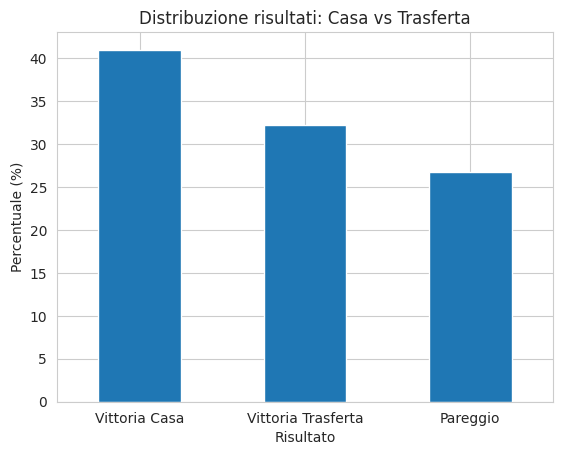

Percentuali risultati Serie A:
  Vittoria Casa: 41.0%
  Vittoria Trasferta: 32.2%
  Pareggio: 26.8%


In [34]:
# ============================================================
# 1) PERCENTUALE RISULTATI: CASA vs TRASFERTA
# ============================================================

# Conta risultati finali
risultati = df['Risultato'].value_counts(normalize=True) * 100

# Rinomina le etichette
risultati.index = risultati.index.map({
    'H': 'Vittoria Casa',
    'A': 'Vittoria Trasferta',
    'D': 'Pareggio'
})

plt.figure()
risultati.plot(kind='bar')
plt.title('Distribuzione risultati: Casa vs Trasferta')
plt.ylabel('Percentuale (%)')
plt.xticks(rotation=0)
plt.show()
print("Percentuali risultati Serie A:")
for label, valore in risultati.items():
    print(f"  {label}: {valore:.1f}%")

Media gol segnati:
Casa         1.494079
Trasferta    1.278947
dtype: float64


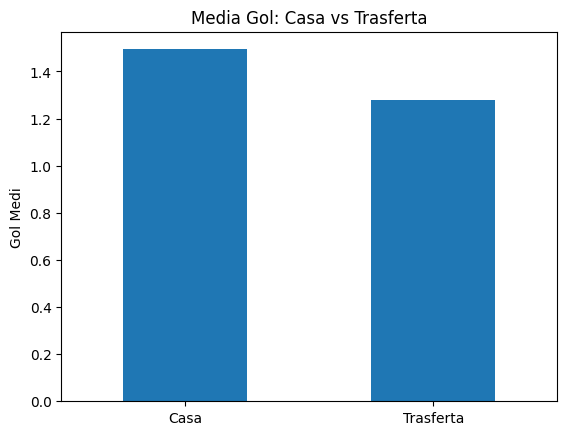

In [24]:
# ============================================================
# MEDIA GOL CASA vs TRASFERTA
# ============================================================

media_gol = {
    'Casa': df['Gol_Casa'].mean(),
    'Trasferta': df['Gol_Trasferta'].mean()
}

media_gol = pd.Series(media_gol)
print("Media gol segnati:")
print(media_gol)

# Grafico
plt.figure()
media_gol.plot(kind='bar')
plt.title('Media Gol: Casa vs Trasferta')
plt.ylabel('Gol Medi')
plt.xticks(rotation=0)
plt.show()


Medie tiri:
Tiri Casa               13.353947
Tiri Trasferta          11.324342
Tiri Porta Casa          4.836184
Tiri Porta Trasferta     4.155263
dtype: float64


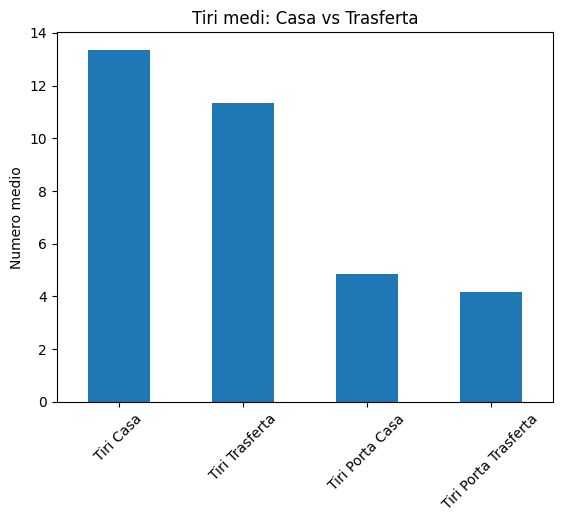

In [25]:
# ============================================================
# DOMINIO DEL GIOCO: TIRI CASA vs TRASFERTA
# ============================================================

media_tiri = {
    'Tiri Casa': df['Tiri_Casa'].mean(),
    'Tiri Trasferta': df['Tiri_Trasferta'].mean(),
    'Tiri Porta Casa': df['Tiri_Porta_Casa'].mean(),
    'Tiri Porta Trasferta': df['Tiri_Porta_Trasferta'].mean()
}

media_tiri = pd.Series(media_tiri)
print("Medie tiri:")
print(media_tiri)

# Grafico
plt.figure()
media_tiri.plot(kind='bar')
plt.title('Tiri medi: Casa vs Trasferta')
plt.ylabel('Numero medio')
plt.xticks(rotation=45)
plt.show()


Media gol subiti:
Gol Subiti in Casa         1.278947
Gol Subiti in Trasferta    1.494079
dtype: float64


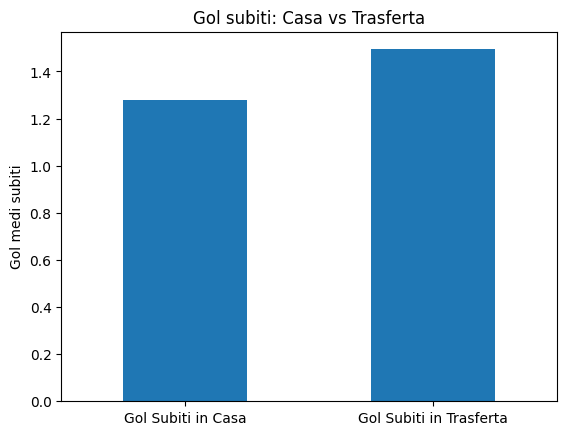

In [26]:
# ============================================================
# ANALISI DIFENSIVA: GOL SUBITI CASA vs TRASFERTA
# ============================================================

gol_subiti = {
    'Gol Subiti in Casa': df['Gol_Trasferta'].mean(),
    'Gol Subiti in Trasferta': df['Gol_Casa'].mean()
}

gol_subiti = pd.Series(gol_subiti)

print("Media gol subiti:")
print(gol_subiti)

# Grafico
plt.figure()
gol_subiti.plot(kind='bar')
plt.title('Gol subiti: Casa vs Trasferta')
plt.ylabel('Gol medi subiti')
plt.xticks(rotation=0)
plt.show()


In [27]:
# 1. Calcoliamo i punti per ogni partita
df['Punti_Casa'] = df['Risultato'].map({'H': 3, 'D': 1, 'A': 0}).astype(int)
df['Punti_Trasferta'] = df['Risultato'].map({'A': 3, 'D': 1, 'H': 0}).astype(int)

# 2. Aggreghiamo i dati per squadra (Media punti a partita)
home_stats = df.groupby('Squadra_Casa')['Punti_Casa'].mean().reset_index()
home_stats.columns = ['Squadra', 'Media_Punti_Casa']

away_stats = df.groupby('Squadra_Trasferta')['Punti_Trasferta'].mean().reset_index()
away_stats.columns = ['Squadra', 'Media_Punti_Trasferta']

# Uniamo i dati
df_comparativo = pd.merge(home_stats, away_stats, on='Squadra')
df_comparativo['Differenza'] = df_comparativo['Media_Punti_Casa'] - df_comparativo['Media_Punti_Trasferta']

# Ordiniamo per chi ha più punti in casa per il grafico
df_comparativo = df_comparativo.sort_values(by='Media_Punti_Casa', ascending=False)

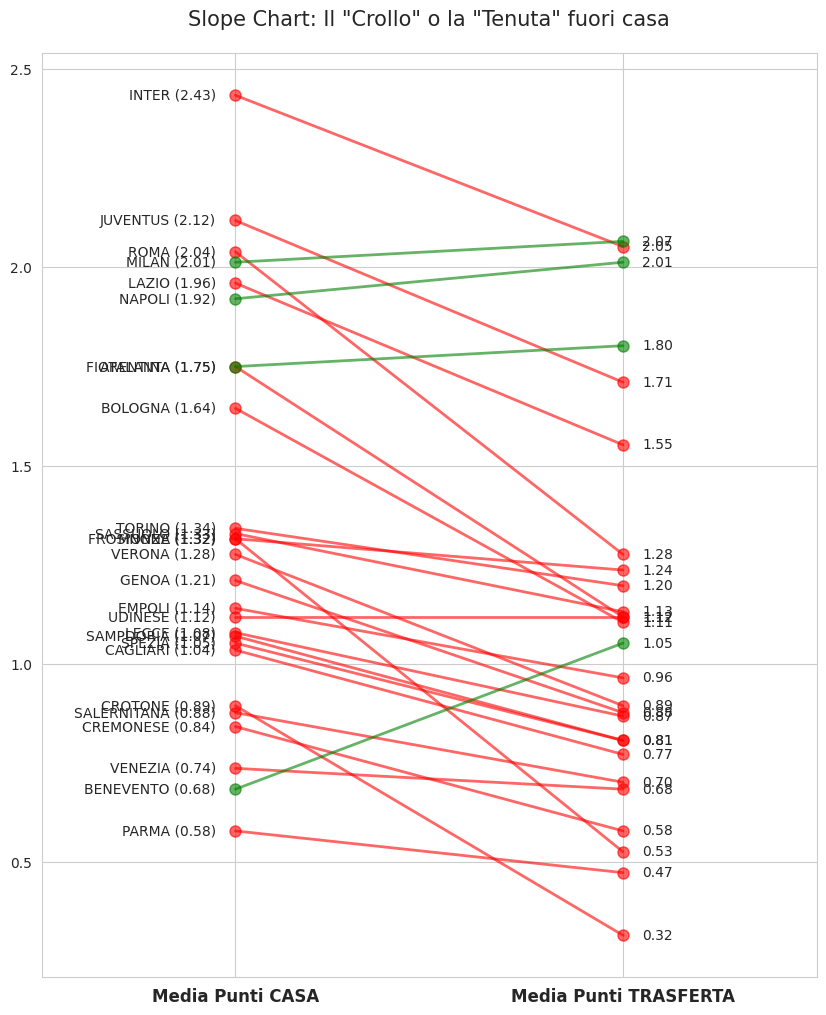

In [28]:
plt.figure(figsize=(10, 12))
sns.set_style("whitegrid")

# Disegniamo le linee per ogni squadra
for i, row in df_comparativo.iterrows():
    color = 'green' if row['Media_Punti_Trasferta'] > row['Media_Punti_Casa'] else 'red'
    plt.plot([0, 1], [row['Media_Punti_Casa'], row['Media_Punti_Trasferta']],
             marker='o', markersize=8, color=color, alpha=0.6, linewidth=2)

    # Etichette nomi squadre
    plt.text(-0.05, row['Media_Punti_Casa'], f"{row['Squadra']} ({row['Media_Punti_Casa']:.2f})",
             ha='right', va='center', fontsize=10)
    plt.text(1.05, row['Media_Punti_Trasferta'], f"{row['Media_Punti_Trasferta']:.2f}",
             ha='left', va='center', fontsize=10)

plt.xticks([0, 1], ['Media Punti CASA', 'Media Punti TRASFERTA'], fontsize=12, fontweight='bold')
plt.title('Slope Chart: Il "Crollo" o la "Tenuta" fuori casa', fontsize=15, pad=20)
plt.xlim(-0.5, 1.5)
plt.show()

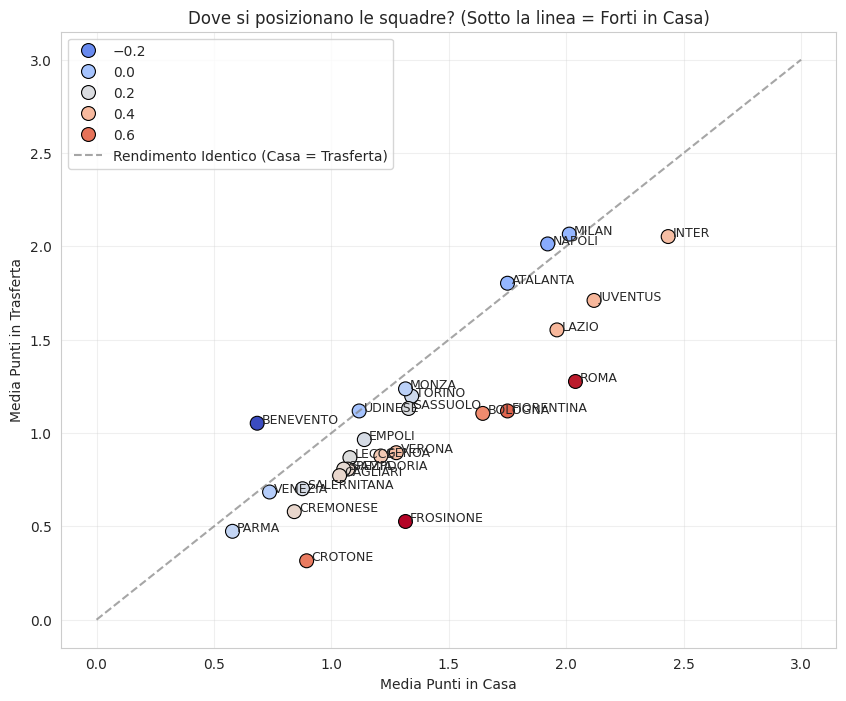

In [29]:
plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(data=df_comparativo, x='Media_Punti_Casa', y='Media_Punti_Trasferta',
                s=100, hue='Differenza', palette='coolwarm', edgecolor='black')

# Linea di bisettrice (y = x)
lims = [0, 3]
plt.plot(lims, lims, '--', color='gray', alpha=0.7, label='Rendimento Identico (Casa = Trasferta)')

# Etichette per le squadre più interessanti
for i, row in df_comparativo.iterrows():
    plt.text(row['Media_Punti_Casa']+0.02, row['Media_Punti_Trasferta'], row['Squadra'], fontsize=9)

plt.xlabel('Media Punti in Casa')
plt.ylabel('Media Punti in Trasferta')
plt.title('Dove si posizionano le squadre? (Sotto la linea = Forti in Casa)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ***5) CASO STUDIO SQUADRA "CAGLIARI 🔴🔵"***

# **Vogliamo verificare:**

Il Cagliari ha una media punti diversa quando gioca contro le big in casa o in trasferta?

Le squadre considerate:

-***Napoli***

-***Roma***

-***Milan***

-***Inter***

-***Juventus***

# 📊 LOGICA DELL’ANALISI (prima del codice)

La logica sarà questa:

1)**Filtrare solo le partite in cui gioca il Cagliari**

2)**Tra queste, selezionare solo quelle contro le 5 big**

3)**Determinare se il Cagliari gioca**:

in casa

in trasferta

4)**Calcolare i punti ottenuti**:

vittoria = 3

pareggio = 1

sconfitta = 0

5)**Calcolare la media punti in casa e media punti fuori**

6)**Creare un grafico a barre comparativo**

Partite CAGLIARI contro le big (NAPOLI, ROMA, MILAN, INTER, JUVENTUS): 30

  RIEPILOGO CAGLIARI vs BIG
  Partite totali : 30
  Vittorie       : 1 (3.3%)
  Pareggi        : 6  (20.0%)
  Sconfitte      : 23 (76.7%)
  Media punti    : 0.30

DETTAGLIO PER AVVERSARIO:
            Partite  Media  Totale
Avversario                        
ROMA              6   0.50       3
NAPOLI            6   0.50       3
INTER             6   0.17       1
MILAN             6   0.17       1
JUVENTUS          6   0.17       1


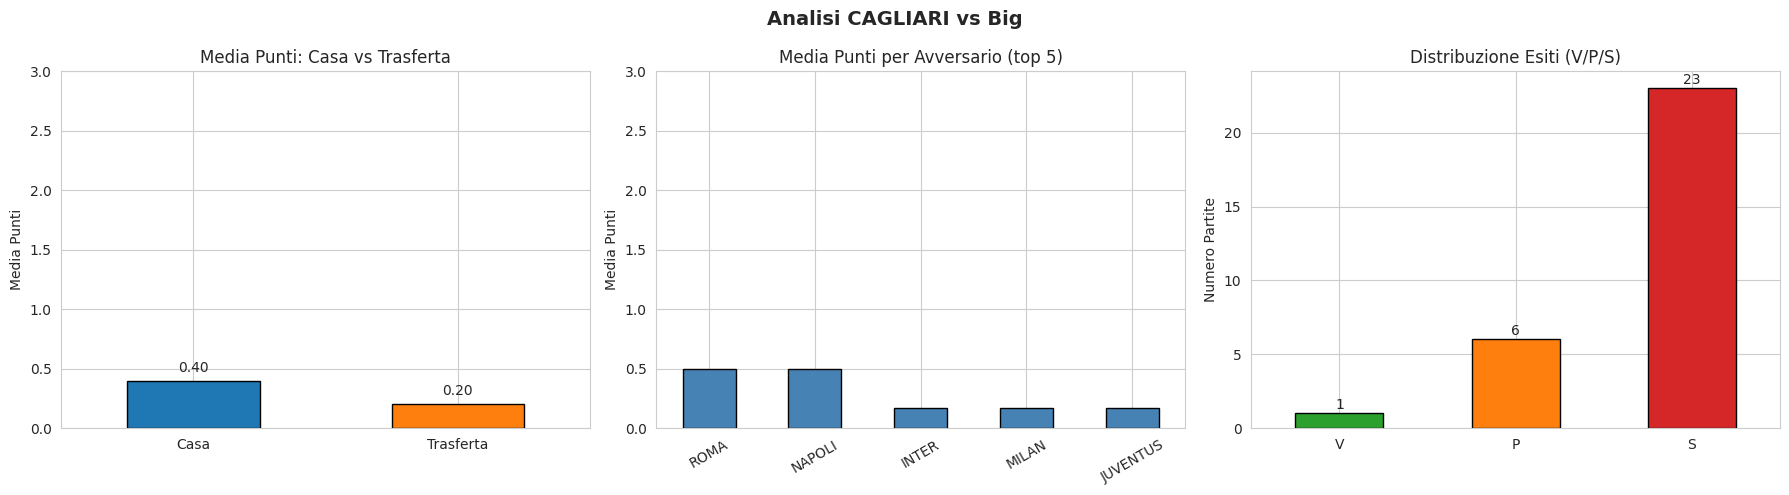

In [30]:
# ============================================================
# CASO STUDIO CAGLIARI MA GENERALIZZABILE: Squadra X contro le Big
# ============================================================

# ──────────────────────────────────────────────
# PARAMETRI — modifica solo questi
# ──────────────────────────────────────────────
SQUADRA_FOCUS = 'CAGLIARI'   # squadra da analizzare
BIG = ['NAPOLI', 'ROMA', 'MILAN', 'INTER', 'JUVENTUS']  # avversari "big"
TOP_N_AVVERSARI = 5          # quante big mostrare nel grafico per avversario
# ──────────────────────────────────────────────


def analisi_squadra_vs_big(df, squadra, big, top_n=5):
    """
    Analizza le prestazioni di `squadra` contro le squadre in `big`.

    Parametri
    ----------
    df       : DataFrame con colonne Squadra_Casa, Squadra_Trasferta, Risultato
    squadra  : str — nome squadra da analizzare (maiuscolo)
    big      : list[str] — lista avversari "big" (maiuscolo)
    top_n    : int — numero di avversari da mostrare nel dettaglio

    Ritorna
    -------
    df_big   : DataFrame filtrato con colonne aggiuntive
    """

    # 1️⃣ Partite della squadra focus
    df_squadra = df[
        (df['Squadra_Casa'] == squadra) | (df['Squadra_Trasferta'] == squadra)
    ]

    # 2️⃣ Filtra solo contro le big
    df_big = df_squadra[
        ((df_squadra['Squadra_Casa']      == squadra) & df_squadra['Squadra_Trasferta'].isin(big)) |
        ((df_squadra['Squadra_Trasferta'] == squadra) & df_squadra['Squadra_Casa'].isin(big))
    ].copy()

    print(f"Partite {squadra} contro le big ({', '.join(big)}): {len(df_big)}")

    # 3️⃣ Punti ottenuti dalla squadra focus
    def calcola_punti(row):
        if row['Squadra_Casa'] == squadra:
            return {'H': 3, 'D': 1}.get(row['Risultato'], 0)
        else:
            return {'A': 3, 'D': 1}.get(row['Risultato'], 0)

    df_big['Punti_Focus']       = df_big.apply(calcola_punti, axis=1)
    df_big['Casa_o_Trasferta']  = df_big.apply(
        lambda r: 'Casa' if r['Squadra_Casa'] == squadra else 'Trasferta', axis=1
    )

    # Colonna avversario (indipendente da dove gioca)
    df_big['Avversario'] = df_big.apply(
        lambda r: r['Squadra_Trasferta'] if r['Squadra_Casa'] == squadra else r['Squadra_Casa'],
        axis=1
    )

    # 4️⃣ Risultato dal punto di vista della squadra focus
    def esito_focus(row):
        if row['Punti_Focus'] == 3: return 'V'
        if row['Punti_Focus'] == 1: return 'P'
        return 'S'

    df_big['Esito_Focus'] = df_big.apply(esito_focus, axis=1)

    return df_big


def plot_analisi(df_big, squadra, top_n=5):
    """Produce 3 grafici: media punti Casa/Trasferta, per avversario, distribuzione esiti."""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Analisi {squadra} vs Big', fontsize=14, fontweight='bold')

    # — Grafico 1: media punti Casa vs Trasferta
    media_ct = df_big.groupby('Casa_o_Trasferta')['Punti_Focus'].mean()
    media_ct.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'], edgecolor='black')
    axes[0].set_title('Media Punti: Casa vs Trasferta')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Media Punti')
    axes[0].set_ylim(0, 3)
    axes[0].tick_params(axis='x', rotation=0)
    for bar in axes[0].patches:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.05,
                     f'{bar.get_height():.2f}',
                     ha='center', va='bottom', fontsize=10)

    # — Grafico 2: media punti per avversario (top_n)
    media_avv = (
        df_big.groupby('Avversario')['Punti_Focus']
              .mean()
              .sort_values(ascending=False)
              .head(top_n)
    )
    media_avv.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
    axes[1].set_title(f'Media Punti per Avversario (top {top_n})')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Media Punti')
    axes[1].set_ylim(0, 3)
    axes[1].tick_params(axis='x', rotation=30)

    # — Grafico 3: distribuzione esiti (V/P/S)
    esiti = df_big['Esito_Focus'].value_counts().reindex(['V', 'P', 'S'], fill_value=0)
    colors = {'V': '#2ca02c', 'P': '#ff7f0e', 'S': '#d62728'}
    esiti.plot(kind='bar', ax=axes[2],
               color=[colors[e] for e in esiti.index], edgecolor='black')
    axes[2].set_title('Distribuzione Esiti (V/P/S)')
    axes[2].set_xlabel('')
    axes[2].set_ylabel('Numero Partite')
    axes[2].tick_params(axis='x', rotation=0)
    for bar in axes[2].patches:
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.1,
                     int(bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


def stampa_riepilogo(df_big, squadra):
    """Stampa un riepilogo testuale dell'analisi."""
    tot      = len(df_big)
    vittorie = (df_big['Esito_Focus'] == 'V').sum()
    pareggi  = (df_big['Esito_Focus'] == 'P').sum()
    sconfitte= (df_big['Esito_Focus'] == 'S').sum()
    media    = df_big['Punti_Focus'].mean()

    print(f"\n{'='*45}")
    print(f"  RIEPILOGO {squadra} vs BIG")
    print(f"{'='*45}")
    print(f"  Partite totali : {tot}")
    print(f"  Vittorie       : {vittorie} ({vittorie/tot*100:.1f}%)")
    print(f"  Pareggi        : {pareggi}  ({pareggi/tot*100:.1f}%)")
    print(f"  Sconfitte      : {sconfitte} ({sconfitte/tot*100:.1f}%)")
    print(f"  Media punti    : {media:.2f}")
    print(f"{'='*45}\n")
    print("DETTAGLIO PER AVVERSARIO:")
    print(
        df_big.groupby('Avversario')['Punti_Focus']
              .agg(Partite='count', Media='mean', Totale='sum')
              .sort_values('Media', ascending=False)
              .round(2)
    )


# ──────────────────────────────────────────────
# ESECUZIONE
# ──────────────────────────────────────────────
df_big = analisi_squadra_vs_big(df, SQUADRA_FOCUS, BIG, TOP_N_AVVERSARI)
stampa_riepilogo(df_big, SQUADRA_FOCUS)
plot_analisi(df_big, SQUADRA_FOCUS, TOP_N_AVVERSARI)

# **Conclusioni e Insights**

Dall'analisi condotta sul dataset, emerge chiaramente che il fattore campo ha un impatto **significativo** sulla performance, confermando le ipotesi iniziali e smentendo qualsiasi tipo di dubbio in merito.

**Punti chiave:**
*   Nel dataset analizzato, la squadra di casa vince in media il 41% delle partite. Questo suggerisce un vantaggio casalingo strutturale, ma la percentuale può variare significativamente in base alla forza relativa delle squadre.
*   Il vantaggio è più marcato per le squadre di medio-bassa classifica  mentre i top team risultano più costanti.

**Interpretazione:**
Il vantaggio  sembra legato a una maggiore efficienza offensiva in casa, suggerendo un impatto psicologico positivo del pubblico e dell'ambiente direzionando cosi' il match verso la squadra di casa.


